In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [2]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# A simple control system
This environment is a simplified, continuous-state, discrete-action Markov Decision Process (MDP) inspired by CartPole. The state at time $t$ is $s_t = (x_t, v_t)$, where $x_t$ is position and $v_t$ is velocity. At each step, the agent chooses an action $a_t \in \{0, 1\}$ (left or right):


\begin{align*}
\text{force} &= 
\begin{cases}
-1 & \text{if } a_t = 0 \\
+1 & \text{if } a_t = 1
\end{cases} \\
v_{t+1} &= v_t + 0.01 \times \text{force} \\
x_{t+1} &= x_t + v_{t+1}
\end{align*}


The reward (the goal is to maintain the position within 2.4) is:
\begin{align*}
r_t = 
\begin{cases}
1.0 & \text{if } |x_{t+1}| < 2.4 \\
-10.0 & \text{otherwise}
\end{cases}
\end{align*}

The episode ends if $|x_{t+1}| >= 2.4$ or after 200 steps.

In [ ]:
# Define a simple environment: CartPole-like (custom, for demonstration)
class SimpleEnv:
    def __init__(self):
        self.state = np.random.uniform(-0.05, 0.05, size=(2,))
        self.t = 0

    def reset(self):
        self.state = np.random.uniform(-0.05, 0.05, size=(2,))
        self.t = 0
        return self.state

    def step(self, action):
        # action: 0 (left), 1 (right)
        x, v = self.state
        force = 1 if action == 1 else -1
        v += 0.01 * force
        x += v
        self.state = np.array([x, v])
        self.t += 1
        reward = 1.0 if abs(x) < 2.4 else -10.0
        done = abs(x) >= 2.4 or self.t >= 400
        return self.state, reward, done, {}

env = SimpleEnv()

# Define a simple policy network
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(2, 2)

    def forward(self, x):
        return F.softmax(self.fc(x), dim=-1)

policy = PolicyNet()
optimizer = optim.Adam(policy.parameters(), lr=0.01)

# REINFORCE algorithm
def select_action(state):
    state = torch.tensor(state, dtype=torch.float32)
    probs = policy(state)
    m = torch.distributions.Categorical(probs)
    action = m.sample()
    return action.item(), m.log_prob(action)

def train(env, policy, optimizer, episodes=200):
    for episode in range(episodes):
        state = env.reset()
        log_probs = []
        rewards = []
        done = False
        while not done:
            action, log_prob = select_action(state)
            next_state, reward, done, _ = env.step(action)
            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state
        # Compute returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + 0.99 * G
            returns.insert(0, G)
        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        loss = -torch.stack(log_probs) * returns
        loss = loss.sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (episode+1) % 50 == 0:
            print(f"Episode {episode+1}, total reward: {sum(rewards)}")

train(env, policy, optimizer, episodes=200)

# Example: run a trained policy
state = env.reset()
done = False
trajectory = [state.copy()]
while not done:
    action, _ = select_action(state)
    state, _, done, _ = env.step(action)
    trajectory.append(state.copy())

trajectory = np.array(trajectory)

Episode 50, total reward: 190.0
Episode 100, total reward: 400.0
Episode 150, total reward: 400.0
Episode 200, total reward: 400.0


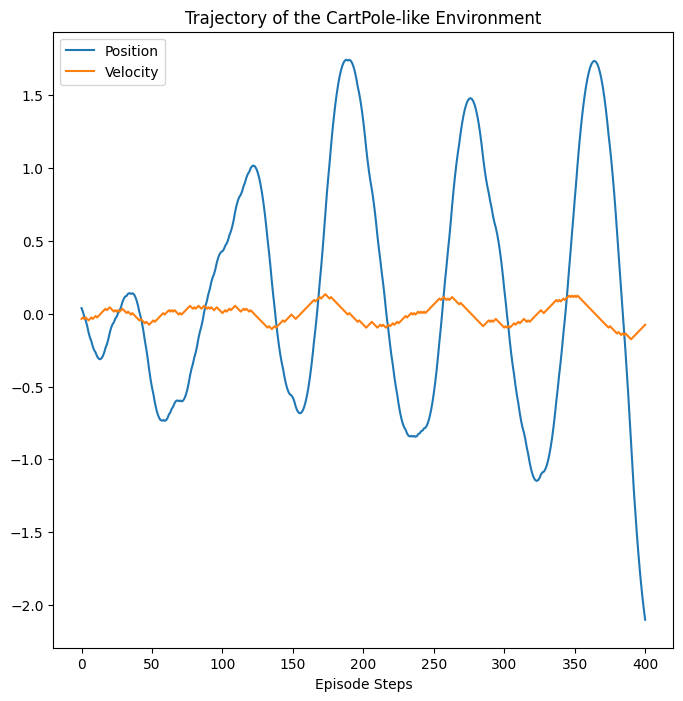

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(trajectory[:, 0], label='Position')
ax.plot(trajectory[:, 1], label='Velocity')
ax.set_xlabel('Episode Steps')
ax.set_title('Trajectory of the CartPole-like Environment')
plt.legend()
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.savefig(f'figures/example-11-1-rl.png', dpi = 300)
plt.show()